In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=64,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=64,
                                          shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 518kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


In [4]:
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiLSTM, self).__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True)

        self.fc = nn.Linear(hidden_size*2, num_classes)  # *2 important

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [5]:
input_size = 28
hidden_size = 128
num_layers = 2
num_classes = 10

model = BiLSTM(input_size, hidden_size, num_layers, num_classes).to(device)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
grad_list = []

num_epochs = 3

for epoch in range(num_epochs):
    for images, labels in train_loader:

        images = images.squeeze(1).permute(0, 2, 1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()

        # store gradient
        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_list.append(param.grad.abs().mean().item())
                break

        optimizer.step()

In [8]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.squeeze(1).permute(0, 2, 1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 97.83%


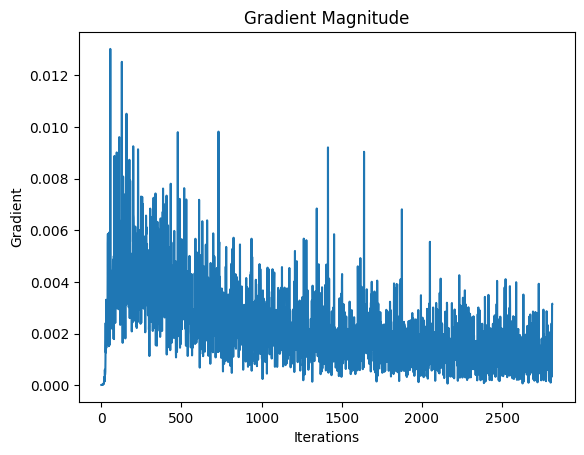

In [9]:
plt.plot(grad_list)
plt.title("Gradient Magnitude")
plt.xlabel("Iterations")
plt.ylabel("Gradient")
plt.show()